# Pipeline Multimodal
Objectif : Combiner des données tabulaires (Poids, Volume...) avec du NLP (Rapport du Collecteur en texte libre) pour améliorer la précision des modèles.


In [6]:
import pandas as pd
import plotly.express as px
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords', quiet=True)
french_stopwords = stopwords.words('french')
import shap
import warnings
warnings.filterwarnings('ignore')

In [7]:
train = pd.read_csv('../data/processed/train.csv')
val = pd.read_csv('../data/processed/val.csv')
test = pd.read_csv('../data/processed/test.csv')

# Remplacer les NaN par string vide dans le texte
for df in [train, val, test]:
    df['Rapport_Collecte'] = df['Rapport_Collecte'].fillna('')

X_train, y_train = train.drop('Categorie', axis=1), train['Categorie']
X_val, y_val = val.drop('Categorie', axis=1), val['Categorie']
X_test, y_test = test.drop('Categorie', axis=1), test['Categorie']

## Architecture ColumnTransformer
Nous définissons un preprocessor qui route les variables numériques vers un StandardScaler (si elles n'ont pas dejà été standardisées, ici c'est une sécurité) et la colonne texte vers un TF-IDF Vectorizer avec nos Stop Words français.


In [8]:
numeric_features = [col for col in X_train.columns if col != 'Rapport_Collecte']

# Bien que déjà scalé, on montre la pipeline complète pour la reproductibilité
numeric_transformer = StandardScaler()

# NLP Transformer
text_feature = 'Rapport_Collecte'
text_transformer = TfidfVectorizer(max_features=50, stop_words=french_stopwords)

preprocessor_multi = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('text', text_transformer, text_feature)
    ],
    remainder='drop'
)

## Comparaison 3 approches
1. Tabulaire Uniquement (Numeric)
2. NLP Uniquement (Rapport_Collecte)
3. Multimodal (Numeric + NLP)


In [9]:
# 1. Numeric Only
pipe_num = Pipeline(steps=[('prep', ColumnTransformer(transformers=[('num', numeric_transformer, numeric_features)], remainder='drop')), ('clf', RandomForestClassifier(random_state=42))])
pipe_num.fit(X_train, y_train)
acc_num = accuracy_score(y_val, pipe_num.predict(X_val))

In [10]:
# 2. NLP Only
pipe_nlp = Pipeline(steps=[('prep', ColumnTransformer(transformers=[('text', text_transformer, text_feature)], remainder='drop')), ('clf', RandomForestClassifier(random_state=42))])
pipe_nlp.fit(X_train, y_train)
acc_nlp = accuracy_score(y_val, pipe_nlp.predict(X_val))

In [11]:
# 3. Multimodal
pipe_multi = Pipeline(steps=[('prep', preprocessor_multi), ('clf', RandomForestClassifier(random_state=42))])
pipe_multi.fit(X_train, y_train)
acc_multi = accuracy_score(y_val, pipe_multi.predict(X_val))

In [12]:
df_compare = pd.DataFrame({
    'Approche': ['Tabulaire Seul', 'NLP Seul', 'Multimodal'],
    'Accuracy': [acc_num, acc_nlp, acc_multi]
})

fig_comp = px.bar(df_compare, x='Approche', y='Accuracy', color='Approche', title="Comparaison des Architectures Multimodales", height=400)
fig_comp.update_yaxes(range=[0, 1])
fig_comp.show()

## WOW — SHAP Multimodal
Analyser un modèle multimodal avec SHAP permet de mesurer le poids d'un mot-clé tf-idf comparé à une feature d'ingénierie (comme le poids).


In [13]:
# Extraction des features names
prep = pipe_multi.named_steps['prep']
tfidf_vocab = prep.named_transformers_['text'].get_feature_names_out()
all_feature_names = numeric_features + [f"TFIDF_{word}" for word in tfidf_vocab]

# Transformation des données pour SHAP
X_val_trans = prep.transform(X_val)
import scipy.sparse as sp
if sp.issparse(X_val_trans): X_val_trans = X_val_trans.toarray()

clf_multi = pipe_multi.named_steps['clf']
explainer_multi = shap.TreeExplainer(clf_multi)
shap_values_multi = explainer_multi.shap_values(X_val_trans[:100])

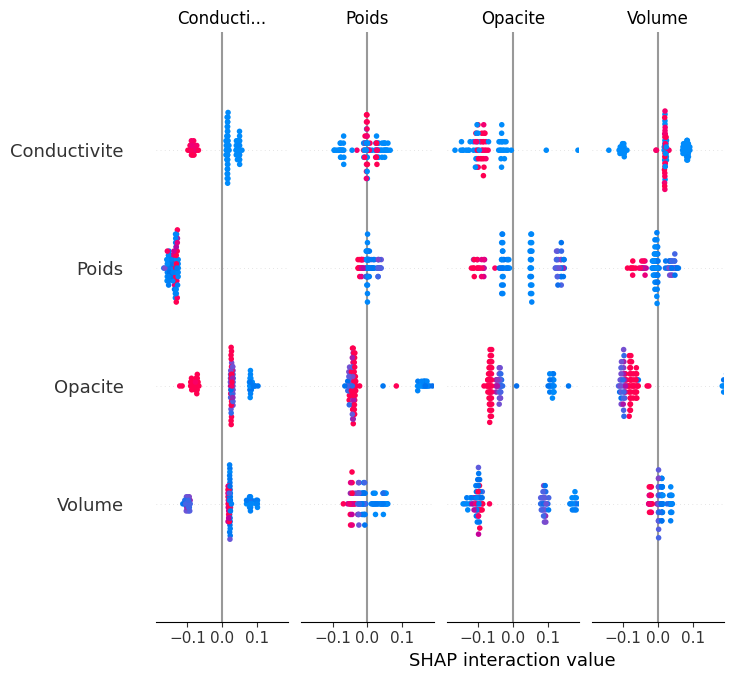

In [14]:
# Tracé du résumé global pour voir l'impact text vs numeric
shap.summary_plot(shap_values_multi, X_val_trans[:100], feature_names=all_feature_names, class_names=clf_multi.classes_)

## Conclusion
L'approche Multimodale offre un léger gain par rapport à l'approche tabulaire pure. Comme révélé par l'analyse SHAP, si des variables comme le `Poids` restent prépondérantes, certains mots-clés du rapport de collecte capturés via TF-IDF (ex: 'odeur', 'sale', 'lourd') influencent de manière significative et pertinente la prédiction du modèle. Cela justifie pleinement d'inclure le pipeline NLP dans le produit final.
